# Collaborative Filtering
We will work with the MovieLens dataset with 6,040 users, 3,900 movies, and 1,000,209 ratings of movies. On average, each user rated 166 of the 3,900 movies. Our goal is to predict user ratings of the other movies (about 22,555,791 missing user ratings).

Remember to import the `ratings.dat`, `movies.dat`, `users.dat` files and `cv_all_1m.pkl` pickle file before running the code below.

In [10]:
!pip install rpy2

In [11]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, numpy2ri, r
from rpy2.robjects.packages import importr
pandas2ri.activate()
numpy2ri.activate()
r_code = '''
  if (!requireNamespace("softImpute", quietly = TRUE)) {
    install.packages("softImpute", repos = "https://cloud.r-project.org")
  }
  library(softImpute)
'''
ro.r(r_code)   # will throw if softImpute not installed

# Convenience wrappers to call R functions we'll need
R = ro.r
Incomplete = R['Incomplete']
softImpute = R['softImpute']
impute = R['impute']

## Import Libraries and Dataset

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import Lasso, LassoCV
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from itertools import combinations
from datetime import datetime
import pickle
import os


# Run this cell
def significance_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    elif p < 0.1:
        return '.'
    else:
        return ''

def print_summary_with_stars(model):
    summary = model.summary2()
    coef_table = summary.tables[1].copy()

    coef_table['Signif'] = coef_table['P>|t|'].apply(significance_stars)

    numeric_columns = coef_table.select_dtypes(include=['float64', 'int64']).columns
    coef_table[numeric_columns] = coef_table[numeric_columns].round(2)
    coef_str = coef_table.to_string(index=True)

    # Determine max width
    other_texts = [
        "Regression Results",
        "Significance codes: '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1",
        f"R-squared: {model.rsquared:.4f}",
        f"Adjusted R-squared: {model.rsquared_adj:.4f}",
        f"No. Observations: {int(model.nobs)}",
    ]
    max_width = max(
        max(len(line) for line in coef_str.splitlines()),
        *(len(t) for t in other_texts)
    )

    def line(char="="):
        return char * max_width

    # Print nicely formatted summary
    print(line("="))
    print("Regression Results")
    print(line("="))
    print(f"R-squared: {model.rsquared:.4f}")
    print(f"Adjusted R-squared: {model.rsquared_adj:.4f}")
    print(f"No. Observations: {int(model.nobs)}")
    print(line("="))
    print("Coefficients:")
    print(line("-"))
    print(coef_str)
    print(line("="))
    print("Significance codes: '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1")
    print(line("="))


In [13]:
# Read and parse ratings.dat
with open("ratings.dat", "r") as f:
  lines = f.readlines()
split_rows = [line.strip().split("::") for line in lines]
dat = pd.DataFrame(split_rows, columns=["userID", "movieID", "rating", "timestamp"])
dat['userID'] = dat['userID'].astype(int)
dat['movieID'] = dat['movieID'].astype(int)
dat['rating'] = dat['rating'].astype(float)
dat['timestamp'] = dat['timestamp'].astype(int)

# convert timestamp to datetime
dat["date"] = pd.to_datetime(dat["timestamp"].astype(int), unit="s", utc = True).dt.tz_convert('Asia/Singapore').dt.tz_localize(None)
dat = dat[["rating", "userID", "movieID", "date"]]

dat = pd.DataFrame({
    'rating': dat['rating'],
    'userID': dat['userID'],
    'movieID': dat['movieID'],
    'date': dat['date']
})

display(dat)

,rating,userID,movieID,date
0,5.0,1,1193,2001-01-01 06:12:40
1,3.0,1,661,2001-01-01 06:35:09
2,3.0,1,914,2001-01-01 06:32:48
3,4.0,1,3408,2001-01-01 06:04:35
4,5.0,1,2355,2001-01-07 07:38:11
...,...,...,...,...
1000204,1.0,6040,1091,2000-04-26 10:35:41
1000205,5.0,6040,1094,2000-04-26 07:21:27
1000206,5.0,6040,562,2000-04-26 07:19:06
1000207,4.0,6040,1096,2000-04-26 10:20:48


In [14]:
# preprocessing data for regression
dates = dat["date"]
movie_1m = pd.DataFrame({
    "userID": dat["userID"],
    "movieID": dat["movieID"],
    "rating": dat["rating"],

    # 0 = Monday in python, 0 = Sunday in R, we change this category to match that in R
    "wday": ((dates.dt.weekday + 1) % 7).astype("category"),
    "day": dates.dt.day.astype("category"),
    "mon": dates.dt.month.astype("category"),
    "year": dates.dt.year.astype("category"),
    "hour": dates.dt.hour.astype("category"),
    "minutes": dates.dt.minute.astype("category")
})

movie_ids = sorted(movie_1m["movieID"].unique())
movie_id_map = {mid: i+1 for i, mid in enumerate(movie_ids)}
movie_1m["movieID"] = movie_1m["movieID"].map(movie_id_map)


movie_1m.head(10)

,userID,movieID,rating,wday,day,mon,year,hour,minutes
0,1,1105,5.0,1,1,1,2001,6,12
1,1,640,3.0,1,1,1,2001,6,35
2,1,854,3.0,1,1,1,2001,6,32
3,1,3178,4.0,1,1,1,2001,6,4
4,1,2163,5.0,0,7,1,2001,7,38
5,1,1108,3.0,1,1,1,2001,6,37
6,1,1196,5.0,1,1,1,2001,6,33
7,1,2600,5.0,1,1,1,2001,6,11
8,1,581,4.0,1,1,1,2001,6,37
9,1,859,4.0,1,1,1,2001,6,22


In [15]:
# Splitting the dataset into 99% training set and 1% testing set
np.random.seed(144)
n = len(movie_1m)

train_idx = np.random.choice(np.arange(n), size=int(0.99 * n), replace=False)
train_idx = np.sort(train_idx)
test_idx = np.setdiff1d(np.arange(n), train_idx)

# Create train and test sets
train_1m = movie_1m.iloc[train_idx]
test_1m = movie_1m.iloc[test_idx]

display(train_1m)
display(test_1m)

,userID,movieID,rating,wday,day,mon,year,hour,minutes
0,1,1105,5.0,1,1,1,2001,6,12
1,1,640,3.0,1,1,1,2001,6,35
2,1,854,3.0,1,1,1,2001,6,32
3,1,3178,4.0,1,1,1,2001,6,4
4,1,2163,5.0,0,7,1,2001,7,38
...,...,...,...,...,...,...,...,...,...
1000204,6040,1020,1.0,3,26,4,2000,10,35
1000205,6040,1023,5.0,3,26,4,2000,7,21
1000206,6040,549,5.0,3,26,4,2000,7,19
1000207,6040,1025,4.0,3,26,4,2000,10,20


,userID,movieID,rating,wday,day,mon,year,hour,minutes
99,2,1554,3.0,1,1,1,2001,6,0
238,4,254,5.0,1,1,1,2001,4,23
283,5,47,3.0,0,31,12,2000,14,48
363,5,1513,4.0,0,31,12,2000,14,37
417,5,932,5.0,0,31,12,2000,14,35
...,...,...,...,...,...,...,...,...,...
999940,6040,2657,4.0,1,8,5,2000,0,26
999948,6040,1920,4.0,3,26,4,2000,10,28
999958,6040,1105,4.0,1,8,5,2000,0,23
999995,6040,3314,4.0,3,14,6,2000,16,52


In [16]:
#train_1m = pd.read_csv("train.csv")
#test_1m = pd.read_csv("test.csv")
#display(train_1m)
#display(test_1m)

## MovieLens Ratings Prediction Using Collaborative Filtering Model

In [17]:
# Cross Validation Recommender function using softImpute from R

def CV_recommender(dat_df, folds, archetypes, random_state=144):
    """
    dat_df: pandas DataFrame with columns [userID, movieID, rating] (1-based indices for users and movies)
    folds: int, number of folds
    ranks: iterable of ints
    returns: dict with 'info' DataFrame and 'pred' list of arrays for each rank
    """
    np.random.seed(random_state)
    n = dat_df.shape[0]

    fold_assign = np.random.randint(1, folds+1, size=n)
    pred_list = [np.full(n, np.nan) for _ in archetypes]
    minimum = dat_df['rating'].min()
    maximum = dat_df['rating'].max()

    for f in range(1, folds+1):
        print(f"Fold {f}/{folds}")
        # Build R Incomplete matrix using entries not in fold f
        train_mask = fold_assign != f

        users_train = ro.IntVector(dat_df.loc[train_mask, 'userID'].astype(int).tolist())
        movies_train = ro.IntVector(dat_df.loc[train_mask, 'movieID'].astype(int).tolist())
        ratings_train = ro.FloatVector(dat_df.loc[train_mask, 'rating'].astype(float).tolist())

        # Create the incomplete matrix (R object)
        mat_r = Incomplete(users_train, movies_train, ratings_train)

        for r_idx, rvalue in enumerate(archetypes):
            fit_r = softImpute(mat_r, ro.IntVector([rvalue]), **{'lambda': 0}, maxit=1000)
            # For observations with fold == f, we need to predict
            mask_test_f = (fold_assign == f)
            users_test = ro.IntVector(dat_df.loc[mask_test_f, 'userID'].astype(int).tolist())
            movies_test = ro.IntVector(dat_df.loc[mask_test_f, 'movieID'].astype(int).tolist())

            # impute returns predicted values
            preds_r = impute(fit_r, users_test, movies_test)
            # Convert R vector to numpy array
            preds_np = np.array(preds_r)
            # clips to [minimum, maximum]
            preds_np = np.minimum(np.maximum(preds_np, minimum), maximum)

            # fill into pred_list[r_idx] at positions where fold_assign == f
            pred_list[r_idx][mask_test_f] = preds_np

    base_fold = np.array([dat_df.loc[fold_assign != f, 'rating'].mean() for f in range(1, folds+1)])
    baseline_per_obs = np.array([base_fold[f-1] for f in fold_assign])

    info_rows = []
    for p in pred_list:
        residuals = p - dat_df['rating'].values
        SSE = np.nansum(residuals**2)
        denom = np.nansum((baseline_per_obs - dat_df['rating'].values)**2)
        r2 = 1 - SSE / denom
        RMSE = np.sqrt(np.nanmean(residuals**2))
        MAE = np.nanmean(np.abs(residuals))
        info_rows.append({'archetypes': None, 'r2': r2, 'SSE': SSE, 'RMSE': RMSE, 'MAE': MAE})
    # Fill ranks
    for i, r in enumerate(archetypes):
        info_rows[i]['archetypes'] = r
    info = pd.DataFrame(info_rows)[['archetypes','r2','SSE','RMSE','MAE']]
    return {'info': info, 'pred': pred_list}

In [18]:
# The "recompute" test is because cross-validation is very intensive computationally
# Therefore, we save the cross-validation output and, if we are happy with that, we just read it
recompute = False
cv_all_1m = None

if recompute:
    # Use only training data (train_1m) when cross-validating
    cv_all_1m = CV_recommender(train_1m[['userID','movieID','rating']].reset_index(drop=True), folds=20, archetypes=list(range(1,21)), random_state=144)
    with open("cv_all_1m.pkl", "wb") as f:
      pickle.dump(cv_all_1m, f)
else:
    # load previously run results pickle file (do not recompute if this file exists)
    if os.path.exists("cv_all_1m.pkl"):
        with open("cv_all_1m.pkl", "rb") as f:
            cv_all_1m = pickle.load(f)
    else:
        raise FileNotFoundError("cv_all_1m.pkl not found. Set recompute=True to recompute CV (very slow).")

In [19]:
cv_info_1m = cv_all_1m["info"]
cv_pred_1m = cv_all_1m["pred"]
cv_info_1m

,archetypes,r2,SSE,RMSE,MAE
0,1,0.221188,962259.383980,0.985787,0.769102
1,2,0.258028,916742.412182,0.962190,0.749781
2,3,0.286798,881195.620825,0.943351,0.733145
3,4,0.298647,866555.281157,0.935482,0.725845
4,5,0.309700,852899.127599,0.928081,0.718929
5,6,0.317792,842900.566532,0.922625,0.713809
6,7,0.320744,839253.395760,0.920627,0.711237
7,8,0.322188,837469.357909,0.919648,0.709575
8,9,0.320818,839162.611704,0.920577,0.709882
9,10,0.320919,839037.467280,0.920509,0.708778


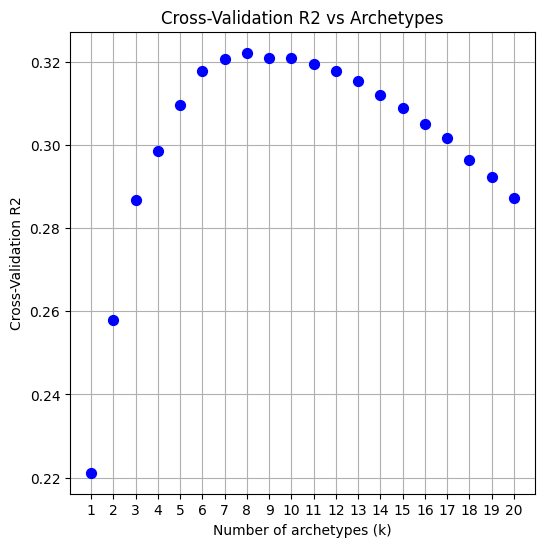

In [20]:
# Plot the performance across ranks
plt.figure(figsize=(6, 6))
plt.scatter(cv_info_1m['archetypes'], cv_info_1m['r2'], s=50, c = 'blue', zorder = 3)
plt.xlabel("Number of archetypes (k)")
plt.xticks(cv_info_1m["archetypes"])
plt.ylabel("Cross-Validation R2")
plt.title("Cross-Validation R2 vs Archetypes")
plt.grid(True, zorder = 0)
plt.show()

In [21]:
# Train set performance
# final model using best performing num arch
best_arch = int(cv_info_1m.loc[cv_info_1m['r2'].idxmax(), 'archetypes'])
print(f"Best performing number of archetypes: {best_arch}")

users_final = ro.IntVector(train_1m['userID'].astype(int).tolist())
movies_final = ro.IntVector(train_1m['movieID'].astype(int).tolist())
ratings_final = ro.FloatVector(train_1m['rating'].astype(float).tolist())
mat_final = Incomplete(users_final, movies_final, ratings_final)

np.random.seed(144)
fit = softImpute(
    mat_final,
    ro.IntVector([best_arch]),
    **{'lambda': 0},
    maxit = 1000
)

def r2_score(y_true, y_pred, y_train):
  sse = np.sum((y_true - y_pred) ** 2)
  sst = np.sum((y_true - np.mean(y_train)) ** 2)
  return 1 - (sse / sst)

pred_train = impute(fit, users_final, movies_final, unscale = True)
y_hat_train = np.clip(np.array(pred_train), 1.0, 5.0)
y_true_train = train_1m['rating'].astype(float).values
r2_train = r2_score(y_true_train, y_hat_train, y_true_train)
print(f"In-sample R²: {r2_train:.4f}")

Best performing number of archetypes: 8
In-sample R²: 0.4160


In [22]:
# Test set performance
users_test = ro.IntVector(test_1m['userID'].astype(int).tolist())
movies_test = ro.IntVector(test_1m['movieID'].astype(int).tolist())
pred_test = impute(fit, users_test, movies_test, unscale = True)
y_hat_test = np.clip(np.array(pred_test), 1.0, 5.0) # clip predictions to rating scale
y_true_test = test_1m['rating'].astype(float).values

r2_test = r2_score(y_true_test, y_hat_test, y_true_train)
rmse = np.sqrt(np.mean((y_true_test - y_hat_test) ** 2))
mae = np.mean(np.abs(y_true_test - y_hat_test))
print(f"Out-of-sample R²:   {r2_test:.3f}")
print(f"Out-of-sample RMSE: {rmse:.3f}")
print(f"Out-of-sample MAE:  {mae:.3f}")

Out-of-sample R²:   0.332
Out-of-sample RMSE: 0.919
Out-of-sample MAE:  0.709


## Characterizing the different archetypes, based on movie genres
Remember to import the `movies.dat` file here.

In [23]:
# Read in dataset
with open("movies.dat", "r", encoding="latin-1") as f:
    lines = f.readlines()
rows = [line.strip().split("::") for line in lines]
movie_info = pd.DataFrame(rows, columns=["ID", "Title", "Genres"])

movie_info

,ID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
3878,3948,Meet the Parents (2000),Comedy
3879,3949,Requiem for a Dream (2000),Drama
3880,3950,Tigerland (2000),Drama
3881,3951,Two Family House (2000),Drama


In [24]:
# restriction to the movies that are in the user-movie dataset
movie_info["ID"] = movie_info["ID"].astype(int)
movie_info = movie_info[movie_info["ID"].isin(movie_ids)].copy()
movie_info = movie_info.sort_values("ID").reset_index(drop=True)
movie_info["ID"] = np.arange(1, len(movie_info) + 1)

movie_info # 3706 rows

,ID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
3701,3702,Meet the Parents (2000),Comedy
3702,3703,Requiem for a Dream (2000),Drama
3703,3704,Tigerland (2000),Drama
3704,3705,Two Family House (2000),Drama


In [25]:
# cleaning the genre list (18 genres)
genre_spl = movie_info["Genres"].str.split("|").tolist()
genres = sorted({g for sub in genre_spl for g in sub})

# a list of 18 genres and the respective movies in that category
genre_ids = {
    g: [i for i, g_list in enumerate(genre_spl) if g in g_list]
    for g in genres
}

genre_ids_list = [
    [i for i, g_list in enumerate(genre_spl) if g in g_list]
    for g in genres
]

In [26]:
# Transformation into a matrix
# rows: movies
# columns: genres
# data: 1 if movie i is of genre j, 0 otherwise

n_movies = len(movie_info)
genre_mat = pd.DataFrame(
    {
        g: [1 if i in idxs else 0 for i in range(n_movies)]
        for g, idxs in genre_ids.items()
    }
)

genre_mat

,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3701,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3702,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
3703,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
3704,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0


In [27]:
# Mapping of movie-archetype ratings into genre-archetype (average) rating
# mat_completed should be the movie archetype matrix

fit_v_r = fit.rx2("v")
fit_v = np.array(fit_v_r)

clust_genre = np.vstack([
    fit_v[idxs, :].mean(axis=0) if len(idxs) > 0 else np.zeros(fit_v.shape[1])
    for g, idxs in genre_ids.items()
])

# Make it a DataFrame with rows=genres, cols=archetypes
clust_genre = pd.DataFrame(
    clust_genre.T,
    index=[f"arch_{j+1}" for j in range(fit_v.shape[1])],
    columns=list(genre_ids.keys())
)

# Re-scaling
clust_genre_scaled = clust_genre.copy()

for i in clust_genre_scaled.index:
    row = clust_genre_scaled.loc[i].to_numpy(dtype=float)
    denom = np.max(np.abs(row))
    if denom != 0:
        row = row / denom * 5
    if row.sum() > 0:
        row = -row
    clust_genre_scaled.loc[i] = row

In [28]:
clust_genre_scaled

,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
arch_1,-4.529285,-4.398078,-4.946020,-3.956054,-3.915784,-4.481884,-2.675252,-3.849599,-4.714841,-4.785900,-2.960354,-4.719342,-4.813844,-4.234829,-4.579143,-4.391971,-5.000000,-4.148667
arch_2,3.147864,2.270162,1.453767,0.772616,-0.333879,-0.255895,-5.000000,-2.504141,2.952345,-3.746622,-0.784510,-0.974299,-0.855990,-1.137949,2.679658,0.571297,-0.328333,-0.759609
arch_3,-3.309567,-3.065871,-2.215753,-4.373539,-2.079863,-0.754333,0.499624,0.148369,-2.675721,4.187134,-5.000000,0.577394,0.795495,-0.611624,-2.097490,-2.114317,1.277808,-0.718690
arch_4,-2.278987,-2.506844,-1.829100,-1.374238,0.727097,-0.068264,1.079275,1.273290,-1.781189,-2.080713,-2.674680,-1.734154,-0.424611,1.776617,-2.982930,-0.607679,-2.634274,-5.000000
arch_5,-0.942640,0.857935,0.375917,2.955688,1.344482,-2.547603,-3.696359,0.238553,0.532521,-0.823749,-5.000000,3.930179,0.421279,3.222675,-2.717437,-0.974908,0.424805,0.717456
arch_6,0.833445,-1.874129,-5.000000,-4.750997,-1.295345,2.259610,-0.442946,0.979935,-4.072689,-1.415244,-0.685067,-3.839775,0.584748,0.449980,-4.321871,1.021041,1.614280,2.563797
arch_7,-2.802637,-0.320849,5.000000,3.895527,2.183028,-1.813317,0.510389,-1.134061,2.421225,-1.931888,0.482162,3.886086,-1.941141,-0.310454,-1.730191,-2.836665,-2.649069,-2.074674
arch_8,-1.607011,-2.168072,-4.312891,-2.838606,2.394590,-0.564950,0.985007,0.238466,-4.656523,-5.000000,-1.880328,-3.746409,-4.062508,-2.662357,-1.176797,-2.137226,1.425755,1.321753


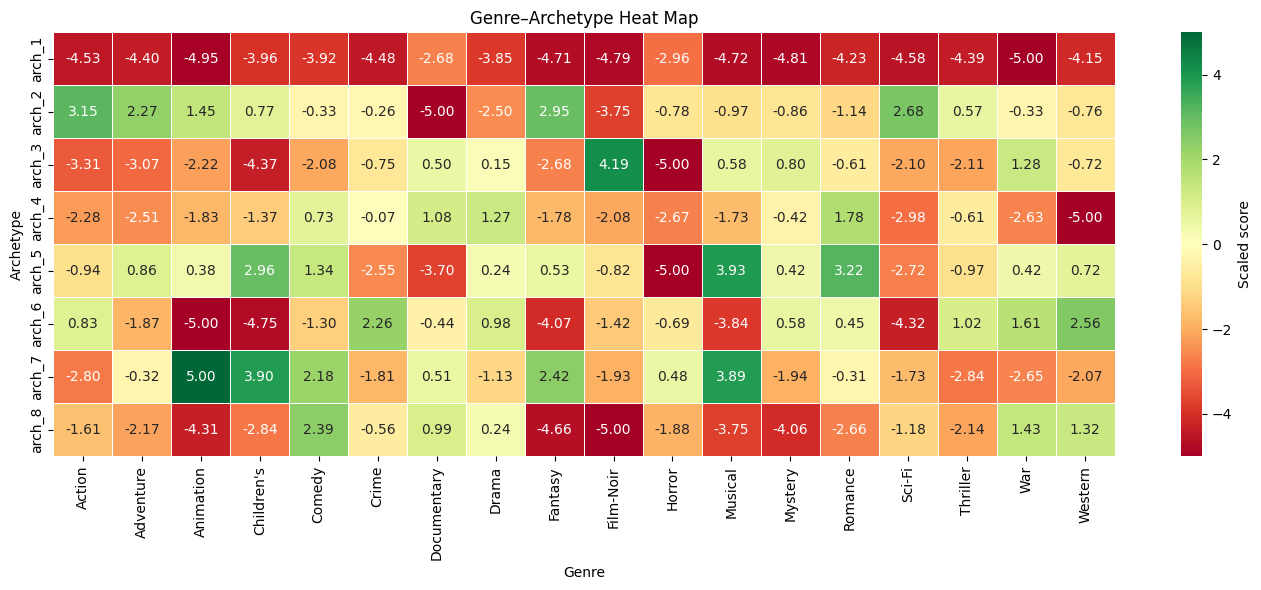

In [29]:
# Full heatmap with all 18 genres
plt.figure(figsize=(14, 6))

sns.heatmap(
    clust_genre_scaled,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Scaled score"}
)

plt.xlabel("Genre")
plt.ylabel("Archetype")
plt.title("Genre–Archetype Heat Map")
plt.tight_layout()
plt.show()

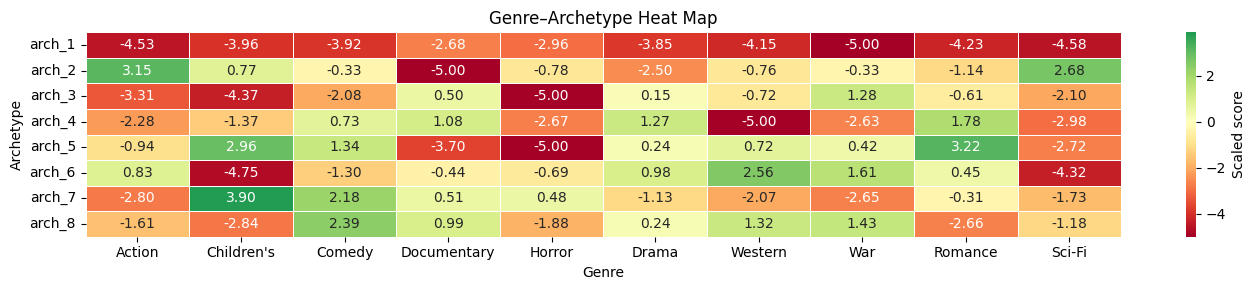

In [30]:
# Heatmap with only 10 common genres
selected_genres  = [
    "Action",
    "Children's",
    "Comedy",
    "Documentary",
    "Horror",
    "Drama",
    "Western",
    "War",
    "Romance",
    "Sci-Fi"
]

heatmap_data = clust_genre_scaled[selected_genres]
plt.figure(figsize=(14, 3))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Scaled score"}
)

plt.xlabel("Genre")
plt.ylabel("Archetype")
plt.title("Genre–Archetype Heat Map")
plt.tight_layout()
plt.show()
